In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path('/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026')
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from deap import base, creator, tools
import warnings
warnings.filterwarnings('ignore')

from src.model import TextCNN
from src.train import train_model, train_proxy
from src.evaluate import evaluate_model, get_predictions, plot_confusion_matrix
from src.dataset import build_vocabulary, load_glove, create_dataloaders
from src.nas_ga import decode, setup_toolbox, run_evolution, plot_evolution
from src.nas_ga import EMBED_OPTS, FILTER_OPTS, KERNEL_OPTS, DROPOUT_OPTS, LR_OPTS

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


In [2]:
RESULTS_DIR = Path('/kaggle/working/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

processed_path = PROJECT_ROOT / 'data' / 'processed' / 'wellfake_processed.csv'
df = pd.read_csv(processed_path)
df['title'] = df['title'].fillna('')
df['text']  = df['text'].fillna('')

print(f'Cargado desde cache: {processed_path}')
print(f'Forma: {df.shape}')
print(f'Columnas: {list(df.columns)}')

from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

word2idx   = build_vocabulary(train_df['text_combined'].tolist(), max_vocab=20000)
VOCAB_SIZE = len(word2idx)

GLOVE_PATH_50  = PROJECT_ROOT / 'data' / 'embeddings' / 'glove.6B.50d.txt'
GLOVE_PATH_100 = PROJECT_ROOT / 'data' / 'embeddings' / 'glove.6B.100d.txt'

emb_matrix_50  = load_glove(str(GLOVE_PATH_50),  word2idx, 50)  if GLOVE_PATH_50.exists()  else None
emb_matrix_100 = load_glove(str(GLOVE_PATH_100), word2idx, 100) if GLOVE_PATH_100.exists() else None

emb_by_dim = {50: emb_matrix_50, 100: emb_matrix_100}

print(f'GloVe 50d  cargado: {emb_matrix_50.shape  if emb_matrix_50  is not None else "NO ENCONTRADO"}')
print(f'GloVe 100d cargado: {emb_matrix_100.shape if emb_matrix_100 is not None else "NO ENCONTRADO"}')
train_loader, val_loader, test_loader = create_dataloaders(
    (train_df['text_combined'].tolist(), train_df['label'].tolist()),
    (val_df['text_combined'].tolist(),   val_df['label'].tolist()),
    (test_df['text_combined'].tolist(),  test_df['label'].tolist()),
    word2idx, batch_size=64, max_len=200)

print(f'Datos listos. Vocab: {VOCAB_SIZE:,}')

Cargado desde cache: /kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/data/processed/wellfake_processed.csv
Forma: (61394, 6)
Columnas: ['title', 'text', 'label', 'title_len', 'text_len', 'text_combined']
GloVe cargado: 19,520 / 20,002 palabras encontradas (97.6% de cobertura)
GloVe cargado: 19,520 / 20,002 palabras encontradas (97.6% de cobertura)
GloVe 50d  cargado: (20002, 50)
GloVe 100d cargado: (20002, 100)
DataLoaders creados:
  Entrenamiento: 49,115 muestras -> 768 batches
  Validacion:    6,139 muestras -> 96 batches
  Prueba:        6,140 muestras -> 96 batches
  Batch size: 64 | Max len: 200
Datos listos. Vocab: 20,002


In [3]:
space_df = pd.DataFrame({
    'Gen': ['G1', 'G2', 'G3', 'G4', 'G5'],
    'Hiperparametro': ['embed_dim', 'num_filters', 'kernel_sizes', 'dropout', 'learning_rate'],
    'Opciones': [str(EMBED_OPTS), str(FILTER_OPTS), str(KERNEL_OPTS), str(DROPOUT_OPTS), str(LR_OPTS)],
    'Tamano': [len(EMBED_OPTS), len(FILTER_OPTS), len(KERNEL_OPTS), len(DROPOUT_OPTS), len(LR_OPTS)],
})
print(space_df.to_string(index=False))
print(f'\nTamano total del espacio: {np.prod(space_df["Tamano"].values)} arquitecturas posibles')

Gen Hiperparametro                          Opciones  Tamano
 G1      embed_dim                         [50, 100]       2
 G2    num_filters                    [64, 128, 256]       3
 G3   kernel_sizes [[3, 4, 5], [2, 3, 4], [3, 5, 7]]       3
 G4        dropout                   [0.3, 0.5, 0.7]       3
 G5  learning_rate             [0.01, 0.001, 0.0005]       3

Tamano total del espacio: 162 arquitecturas posibles


In [4]:
for ind in [[0,0,0,0,0], [1,2,0,1,2], [0,1,1,2,1]]:
    config = decode(ind)
    print(f'Cromosoma {ind} -> {config}')

Cromosoma [0, 0, 0, 0, 0] -> {'embed_dim': 50, 'num_filters': 64, 'kernel_sizes': [3, 4, 5], 'dropout': 0.3, 'lr': 0.01}
Cromosoma [1, 2, 0, 1, 2] -> {'embed_dim': 100, 'num_filters': 256, 'kernel_sizes': [3, 4, 5], 'dropout': 0.5, 'lr': 0.0005}
Cromosoma [0, 1, 1, 2, 1] -> {'embed_dim': 50, 'num_filters': 128, 'kernel_sizes': [2, 3, 4], 'dropout': 0.7, 'lr': 0.001}


In [5]:
eval_count = [0]  # contador de evaluaciones

def evaluate_individual(individual):
    """Evalua un individuo: crea TextCNN, entrena proxy, devuelve (F1,)."""
    config = decode(individual)
    eval_count[0] += 1

    emb = emb_by_dim.get(config['embed_dim'])

    torch.manual_seed(42)
    model = TextCNN(
        vocab_size=VOCAB_SIZE,
        embed_dim=config['embed_dim'],
        num_filters=config['num_filters'],
        kernel_sizes=config['kernel_sizes'],
        dropout=config['dropout'],
        pretrained_embeddings=emb,
    ).to(device)

    f1 = train_proxy(model, train_loader, val_loader, device, epochs=3, data_fraction=0.3)

    print(f'  [{eval_count[0]:3d}] {individual} -> F1={f1:.4f} | {config}')
    return (f1,)

print('Funcion evaluate_individual definida.')

Funcion evaluate_individual definida.


In [6]:
toolbox = setup_toolbox(evaluate_individual)

print('Iniciando evolucion...')
print('=' * 70)
result_pop, logbook = run_evolution(toolbox, pop_size=10, ngen=10, cxpb=0.7, mutpb=0.3)
print('=' * 70)
print(f'Evolucion completada. Total evaluaciones: {eval_count[0]}')

Iniciando evolucion...
  [  1] [0, 1, 2, 2, 0] -> F1=0.9299 | {'embed_dim': 50, 'num_filters': 128, 'kernel_sizes': [3, 5, 7], 'dropout': 0.7, 'lr': 0.01}
  [  2] [1, 1, 0, 1, 2] -> F1=0.9469 | {'embed_dim': 100, 'num_filters': 128, 'kernel_sizes': [3, 4, 5], 'dropout': 0.5, 'lr': 0.0005}
  [  3] [1, 1, 0, 0, 1] -> F1=0.9486 | {'embed_dim': 100, 'num_filters': 128, 'kernel_sizes': [3, 4, 5], 'dropout': 0.3, 'lr': 0.001}
  [  4] [1, 1, 0, 1, 0] -> F1=0.9466 | {'embed_dim': 100, 'num_filters': 128, 'kernel_sizes': [3, 4, 5], 'dropout': 0.5, 'lr': 0.01}
  [  5] [0, 0, 0, 0, 0] -> F1=0.9341 | {'embed_dim': 50, 'num_filters': 64, 'kernel_sizes': [3, 4, 5], 'dropout': 0.3, 'lr': 0.01}
  [  6] [0, 0, 1, 1, 2] -> F1=0.9254 | {'embed_dim': 50, 'num_filters': 64, 'kernel_sizes': [2, 3, 4], 'dropout': 0.5, 'lr': 0.0005}
  [  7] [0, 2, 2, 1, 0] -> F1=0.9382 | {'embed_dim': 50, 'num_filters': 256, 'kernel_sizes': [3, 5, 7], 'dropout': 0.5, 'lr': 0.01}
  [  8] [1, 2, 0, 1, 2] -> F1=0.9519 | {'embed_

In [7]:
log_df = pd.DataFrame(logbook)
log_path = RESULTS_DIR / 'nas_logbook.csv'
log_df.to_csv(log_path, index=False)
print(f'Logbook guardado en {log_path}')
print(log_df.to_string(index=False))

Logbook guardado en /kaggle/working/results/nas_logbook.csv
 gen  nevals      max      avg
   0      10 0.951930 0.938205
   1      10 0.948815 0.941399
   2      10 0.952779 0.945387
   3       8 0.952779 0.949096
   4       9 0.953003 0.949242
   5       7 0.953417 0.951754
   6      10 0.953108 0.950721
   7      10 0.953590 0.951682
   8       8 0.953159 0.952621
   9      10 0.953159 0.947331
  10       9 0.953522 0.952569


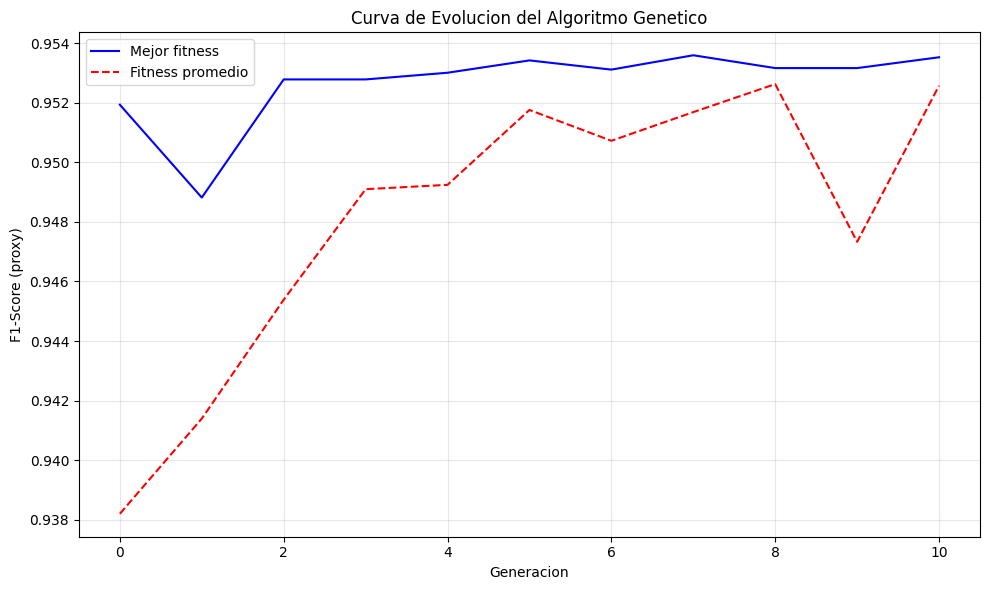

In [8]:
plot_evolution(logbook)

In [9]:
best_ind    = tools.selBest(result_pop, k=1)[0]
best_config = decode(best_ind)
proxy_f1    = best_ind.fitness.values[0]

print(f'Mejor cromosoma: {best_ind}')
print(f'Configuracion:   {best_config}')
print(f'F1 proxy:        {proxy_f1:.4f}')

# Entrenar completamente (10-15 epocas, 100% de los datos)
print(f'\nEntrenando modelo completo con la mejor configuracion...')
best_emb = emb_by_dim.get(best_config['embed_dim'])
torch.manual_seed(42)
best_model = TextCNN(
    vocab_size=VOCAB_SIZE, embed_dim=best_config['embed_dim'],
    num_filters=best_config['num_filters'], kernel_sizes=best_config['kernel_sizes'],
    dropout=best_config['dropout'], pretrained_embeddings=best_emb,
).to(device)
opt  = torch.optim.Adam(best_model.parameters(), lr=best_config['lr'])
crit = nn.BCEWithLogitsLoss()
hist = train_model(best_model, train_loader, val_loader, opt, crit, device, num_epochs=15, patience=3)

test_metrics = evaluate_model(best_model, test_loader, crit, device)
print(f'\n=== Resultados en Test (modelo evolucionado, entrenamiento completo) ===')
for k, v in test_metrics.items():
    print(f'  {k:>10s}: {v:.4f}')

full_f1 = test_metrics['f1']

Mejor cromosoma: [1, 2, 0, 1, 1]
Configuracion:   {'embed_dim': 100, 'num_filters': 256, 'kernel_sizes': [3, 4, 5], 'dropout': 0.5, 'lr': 0.001}
F1 proxy:        0.9535

Entrenando modelo completo con la mejor configuracion...
Epoch 01/15 | Train Loss: 0.1896  Train F1: 0.9111 | Val Loss: 0.1085  Val F1: 0.9501
Epoch 02/15 | Train Loss: 0.0837  Train F1: 0.9644 | Val Loss: 0.0934  Val F1: 0.9552
Epoch 03/15 | Train Loss: 0.0447  Train F1: 0.9821 | Val Loss: 0.0966  Val F1: 0.9614
Epoch 04/15 | Train Loss: 0.0218  Train F1: 0.9921 | Val Loss: 0.1160  Val F1: 0.9585
Epoch 05/15 | Train Loss: 0.0123  Train F1: 0.9956 | Val Loss: 0.1583  Val F1: 0.9560
Epoch 06/15 | Train Loss: 0.0089  Train F1: 0.9968 | Val Loss: 0.1541  Val F1: 0.9581

Early stopping en epoca 6. Mejor Val F1: 0.9614

=== Resultados en Test (modelo evolucionado, entrenamiento completo) ===
        loss: 0.0975
    accuracy: 0.9668
          f1: 0.9626
   precision: 0.9594
      recall: 0.9658


In [10]:
print(f'F1 proxy (3 epocas, 30% datos):   {proxy_f1:.4f}')
print(f'F1 completo (test, full train):   {full_f1:.4f}')
print(f'Diferencia:                       {abs(full_f1 - proxy_f1):.4f}')
print(f"\n¿El proxy fue confiable? {'Si' if abs(full_f1 - proxy_f1) < 0.05 else 'No'} "
      f"(diferencia {'<' if abs(full_f1 - proxy_f1) < 0.05 else '>'} 0.05)")

F1 proxy (3 epocas, 30% datos):   0.9535
F1 completo (test, full train):   0.9626
Diferencia:                       0.0090

¿El proxy fue confiable? Si (diferencia < 0.05)


In [13]:
manual_csv = PROJECT_ROOT / "results" / 'experiments.csv'
if manual_csv.exists():
    manual_df = pd.read_csv(manual_csv)
    manual_df['val_f1_num'] = manual_df['val_f1'].astype(float)
    best_manual = manual_df.loc[manual_df['val_f1_num'].idxmax()]
    manual_f1   = float(best_manual['test_f1'])
else:
    manual_f1 = 0.0
    print(f'No se encontraron resultados manuales en {manual_csv}.')

comparison = pd.DataFrame({
    'Metodo':         ['Manual (Reto 5)', 'AG Evolucionado'],
    'Configuracion':  [str(best_manual['config']) if manual_csv.exists() else 'N/A', str(best_config)],
    'Test F1':        [f'{manual_f1:.4f}', f'{full_f1:.4f}'],
    'Test Acc':       [str(best_manual.get('test_accuracy', 'N/A')) if manual_csv.exists() else 'N/A',
                       f"{test_metrics['accuracy']:.4f}"],
})

print('\n' + '=' * 70)
print('COMPARACION: Manual vs. Evolucionado')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)

winner = 'AG' if full_f1 > manual_f1 else 'Manual'
print(f'\nGanador: {winner} (diferencia de F1: {abs(full_f1 - manual_f1):.4f})')


COMPARACION: Manual vs. Evolucionado
         Metodo                                                                                  Configuracion Test F1 Test Acc
Manual (Reto 5)                             {'lr': 0.001, 'num_filters': 350, 'dropout': 0.0, 'embed_dim': 50}  0.9617   0.9658
AG Evolucionado {'embed_dim': 100, 'num_filters': 256, 'kernel_sizes': [3, 4, 5], 'dropout': 0.5, 'lr': 0.001}  0.9626   0.9668

Ganador: AG (diferencia de F1: 0.0009)


# Análisis

¿Convergió el AG?
Sí. El fitness máximo se estabilizó alrededor de 0.953 desde las primeras generaciones, y varios individuos se volvieron genéticamente idénticos (caída en `nevals` de 10 a 5-8), señal clara de convergencia.

¿La arquitectura evolucionada fue mejor?
Sí, por un margen pequeño pero real: el AG obtuvo test_f1=0.9626 frente al 0.9617 del mejor resultado manual del Reto 5, una mejora de +0.0009, lograda con una combinación conjunta de hiperparámetros que la búsqueda manual (uno a la vez) nunca exploró directamente.